In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# set paths

project_dir = r"C:\Users\kjdac\OneDrive\Desktop\PORTFOLIO PROJECTS\Health_Insurance_claims_member_engagement"

processed_dir = os.path.join(project_dir, "data_processed")
outputs_dir = os.path.join(project_dir, "outputs")
tables_dir = os.path.join(outputs_dir, "tables")
charts_dir = os.path.join(outputs_dir, "charts")

os.makedirs(outputs_dir, exist_ok=True)
os.makedirs(tables_dir, exist_ok=True)
os.makedirs(charts_dir, exist_ok=True)

print("Processed dir:", processed_dir)
print("Charts dir:", charts_dir)

Processed dir: C:\Users\kjdac\OneDrive\Desktop\PORTFOLIO PROJECTS\Health_Insurance_claims_member_engagement\data_processed
Charts dir: C:\Users\kjdac\OneDrive\Desktop\PORTFOLIO PROJECTS\Health_Insurance_claims_member_engagement\outputs\charts


In [3]:
# load member-level dataset

member_features = pd.read_csv(
    os.path.join(processed_dir, "member_features_2010.csv"),
    low_memory=False
)

print("member_features shape:", member_features.shape)
member_features.head()

member_features shape: (112754, 57)


,DESYNPUF_ID,BENE_BIRTH_DT,BENE_DEATH_DT,BENE_SEX_IDENT_CD,BENE_RACE_CD,BENE_ESRD_IND,SP_STATE_CODE,BENE_COUNTY_CD,BENE_HI_CVRAGE_TOT_MONS,BENE_SMI_CVRAGE_TOT_MONS,...,outpatient_total_primary_payer_paid,outpatient_total_deductible,outpatient_total_coinsurance,outpatient_total_blood_deductible,outpatient_avg_diag_count,has_outpatient_claim,age_2010,chronic_condition_count,total_paid_all_claims,high_cost_member
0,00013D2EFD8E45D1,1970-01-01 00:00:00.019230501,NaN,1,1,0,26,950,12,12,...,0.0,0.0,10.0,0.0,2.0,1.0,40.99384,2,4050.0,0
1,00016F745862898F,1970-01-01 00:00:00.019430101,NaN,1,1,Y,39,230,12,12,...,0.0,0.0,70.0,0.0,4.5,1.0,40.99384,4,52060.0,1
2,0001FDD721E223DC,1970-01-01 00:00:00.019360901,NaN,2,1,0,39,280,12,12,...,0.0,0.0,50.0,0.0,4.0,1.0,40.99384,0,30.0,0
3,00021CA6FF03E670,1970-01-01 00:00:00.019410601,NaN,1,5,0,6,290,12,12,...,0.0,0.0,0.0,0.0,0.0,0.0,40.99384,0,0.0,0
4,00024B3D2352D2D0,1970-01-01 00:00:00.019360801,NaN,1,1,0,52,590,9,12,...,0.0,0.0,80.0,0.0,1.5,1.0,40.99384,0,160.0,0


In [4]:
# convert date columns if needed

date_cols = ["BENE_BIRTH_DT", "BENE_DEATH_DT"]

for col in date_cols:
    member_features[col] = pd.to_datetime(member_features[col], errors="coerce")

member_features[date_cols].dtypes

BENE_BIRTH_DT    datetime64[ns]
BENE_DEATH_DT    datetime64[ns]
dtype: object

In [5]:
# quick dataset overview

print("Rows, columns:", member_features.shape)
print("\nColumn names:")
for col in member_features.columns:
    print(col)

Rows, columns: (112754, 57)

Column names:
DESYNPUF_ID
BENE_BIRTH_DT
BENE_DEATH_DT
BENE_SEX_IDENT_CD
BENE_RACE_CD
BENE_ESRD_IND
SP_STATE_CODE
BENE_COUNTY_CD
BENE_HI_CVRAGE_TOT_MONS
BENE_SMI_CVRAGE_TOT_MONS
BENE_HMO_CVRAGE_TOT_MONS
PLAN_CVRG_MOS_NUM
SP_ALZHDMTA
SP_CHF
SP_CHRNKIDN
SP_CNCR
SP_COPD
SP_DEPRESSN
SP_DIABETES
SP_ISCHMCHT
SP_OSTEOPRS
SP_RA_OA
SP_STRKETIA
MEDREIMB_IP
BENRES_IP
PPPYMT_IP
MEDREIMB_OP
BENRES_OP
PPPYMT_OP
MEDREIMB_CAR
BENRES_CAR
PPPYMT_CAR
inpatient_claim_count
inpatient_total_paid
inpatient_avg_paid
inpatient_max_paid
inpatient_total_primary_payer_paid
inpatient_total_deductible
inpatient_total_coinsurance
inpatient_total_blood_deductible
inpatient_total_util_days
inpatient_avg_diag_count
has_inpatient_claim
outpatient_claim_count
outpatient_total_paid
outpatient_avg_paid
outpatient_max_paid
outpatient_total_primary_payer_paid
outpatient_total_deductible
outpatient_total_coinsurance
outpatient_total_blood_deductible
outpatient_avg_diag_count
has_outpatient_claim
ag

In [6]:
# missing summary

missing_summary = (
    member_features.isnull()
    .sum()
    .reset_index()
)

missing_summary.columns = ["column_name", "missing_count"]
missing_summary["missing_pct"] = (
    missing_summary["missing_count"] / len(member_features) * 100
).round(2)

missing_summary = missing_summary.sort_values(
    by="missing_count", ascending=False
)

missing_summary.head(20)

,column_name,missing_count,missing_pct
2,BENE_DEATH_DT,110891,98.35
0,DESYNPUF_ID,0,0.00
1,BENE_BIRTH_DT,0,0.00
3,BENE_SEX_IDENT_CD,0,0.00
4,BENE_RACE_CD,0,0.00
5,BENE_ESRD_IND,0,0.00
6,SP_STATE_CODE,0,0.00
7,BENE_COUNTY_CD,0,0.00
8,BENE_HI_CVRAGE_TOT_MONS,0,0.00
9,BENE_SMI_CVRAGE_TOT_MONS,0,0.00


In [7]:
missing_summary.to_csv(
    os.path.join(tables_dir, "missingness_summary_member_features.csv"),
    index=False
)

print("Saved missingness summary.")

Saved missingness summary.


In [8]:
# check for member duplicates

duplicate_member_ids = member_features["DESYNPUF_ID"].duplicated().sum()

print("Duplicate DESYNPUF_ID rows:", duplicate_member_ids)

Duplicate DESYNPUF_ID rows: 0


In [9]:
# basic summary stats

member_features[[
    "age_2010",
    "chronic_condition_count",
    "inpatient_claim_count",
    "outpatient_claim_count",
    "inpatient_total_paid",
    "outpatient_total_paid",
    "total_paid_all_claims"
]].describe()

,age_2010,chronic_condition_count,inpatient_claim_count,outpatient_claim_count,inpatient_total_paid,outpatient_total_paid,total_paid_all_claims
count,1.127540e+05,112754.000000,112754.000000,112754.000000,112754.000000,112754.000000,112754.000000
mean,4.099384e+01,1.800770,0.584946,6.929244,5600.853806,1964.241446,7565.095252
std,1.779207e-11,1.988318,1.106214,8.194271,13132.368467,5307.449284,15433.871975
min,4.099384e+01,0.000000,0.000000,0.000000,-3000.000000,-100.000000,-2860.000000
25%,4.099384e+01,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000
50%,4.099384e+01,1.000000,0.000000,4.000000,0.000000,600.000000,1270.000000
75%,4.099384e+01,3.000000,1.000000,11.000000,5000.000000,2300.000000,8200.000000
max,4.099384e+01,11.000000,14.000000,78.000000,209000.000000,133380.000000,244180.000000


In [10]:
# create data quality flags table

dq = member_features.copy()

dq["flag_missing_birth_date"] = dq["BENE_BIRTH_DT"].isna().astype(int)
dq["flag_age_negative"] = (dq["age_2010"] < 0).astype(int)
dq["flag_age_over_115"] = (dq["age_2010"] > 115).astype(int)

dq["flag_negative_inpatient_paid"] = (dq["inpatient_total_paid"] < 0).astype(int)
dq["flag_negative_outpatient_paid"] = (dq["outpatient_total_paid"] < 0).astype(int)
dq["flag_negative_total_paid"] = (dq["total_paid_all_claims"] < 0).astype(int)

dq["flag_negative_inpatient_claim_count"] = (dq["inpatient_claim_count"] < 0).astype(int)
dq["flag_negative_outpatient_claim_count"] = (dq["outpatient_claim_count"] < 0).astype(int)

dq["flag_zero_claims_but_positive_paid"] = (
    (
        (dq["inpatient_claim_count"] == 0) & (dq["inpatient_total_paid"] > 0)
    ) |
    (
        (dq["outpatient_claim_count"] == 0) & (dq["outpatient_total_paid"] > 0)
    )
).astype(int)

dq["flag_death_before_birth"] = (
    (dq["BENE_DEATH_DT"].notna()) &
    (dq["BENE_BIRTH_DT"].notna()) &
    (dq["BENE_DEATH_DT"] < dq["BENE_BIRTH_DT"])
).astype(int)

dq["flag_death_before_2010"] = (
    (dq["BENE_DEATH_DT"].notna()) &
    (dq["BENE_DEATH_DT"] < pd.Timestamp("2010-01-01"))
).astype(int)

In [11]:
# summarize QA flags

dq_flag_cols = [col for col in dq.columns if col.startswith("flag_")]

dq_flag_summary = pd.DataFrame({
    "flag_name": dq_flag_cols,
    "flag_count": [dq[col].sum() for col in dq_flag_cols]
})

dq_flag_summary["flag_pct"] = (
    dq_flag_summary["flag_count"] / len(dq) * 100
).round(2)

dq_flag_summary = dq_flag_summary.sort_values(
    by="flag_count", ascending=False
)

dq_flag_summary

,flag_name,flag_count,flag_pct
10,flag_death_before_2010,1863,1.65
4,flag_negative_outpatient_paid,47,0.04
5,flag_negative_total_paid,41,0.04
3,flag_negative_inpatient_paid,21,0.02
2,flag_age_over_115,0,0.00
0,flag_missing_birth_date,0,0.00
1,flag_age_negative,0,0.00
6,flag_negative_inpatient_claim_count,0,0.00
7,flag_negative_outpatient_claim_count,0,0.00
8,flag_zero_claims_but_positive_paid,0,0.00


In [12]:
# save data quality summary

dq_flag_summary.to_csv(
    os.path.join(tables_dir, "data_quality_flag_summary.csv"),
    index=False
)

print("Saved data quality flag summary.")

Saved data quality flag summary.


In [13]:
# save flagged records for review

flagged_records = dq.loc[
    dq[dq_flag_cols].sum(axis=1) > 0,
    ["DESYNPUF_ID"] + dq_flag_cols
]

flagged_records.to_csv(
    os.path.join(tables_dir, "flagged_member_records.csv"),
    index=False
)

print("Flagged records shape:", flagged_records.shape)

Flagged records shape: (1930, 12)


In [14]:
# value counts for key categorical variables

print("Sex code counts:")
print(member_features["BENE_SEX_IDENT_CD"].value_counts(dropna=False))

print("\nRace code counts:")
print(member_features["BENE_RACE_CD"].value_counts(dropna=False))

print("\nESRD indicator counts:")
print(member_features["BENE_ESRD_IND"].value_counts(dropna=False))

Sex code counts:
BENE_SEX_IDENT_CD
2    62368
1    50386
Name: count, dtype: int64

Race code counts:
BENE_RACE_CD
1    93343
2    11962
3     4793
5     2656
Name: count, dtype: int64

ESRD indicator counts:
BENE_ESRD_IND
0    104737
Y      8017
Name: count, dtype: int64


In [15]:
# chronic condition prevalnce 

chronic_cols = [
    "SP_ALZHDMTA",
    "SP_CHF",
    "SP_CHRNKIDN",
    "SP_CNCR",
    "SP_COPD",
    "SP_DEPRESSN",
    "SP_DIABETES",
    "SP_ISCHMCHT",
    "SP_OSTEOPRS",
    "SP_RA_OA",
    "SP_STRKETIA"
]

chronic_summary = []

for col in chronic_cols:
    chronic_summary.append({
        "condition_flag": col,
        "positive_count": (member_features[col] == 1).sum(),
        "positive_pct": round((member_features[col] == 1).mean() * 100, 2)
    })

chronic_summary = pd.DataFrame(chronic_summary).sort_values(
    by="positive_count", ascending=False
)

chronic_summary

,condition_flag,positive_count,positive_pct
7,SP_ISCHMCHT,42165,37.40
6,SP_DIABETES,32978,29.25
1,SP_CHF,29159,25.86
5,SP_DEPRESSN,20042,17.77
0,SP_ALZHDMTA,18689,16.58
2,SP_CHRNKIDN,15619,13.85
8,SP_OSTEOPRS,14691,13.03
9,SP_RA_OA,10912,9.68
4,SP_COPD,10105,8.96
3,SP_CNCR,5733,5.08


In [16]:
# save chronic condition summary

chronic_summary.to_csv(
    os.path.join(tables_dir, "chronic_condition_summary.csv"),
    index=False
)

print("Saved chronic condition summary.")

Saved chronic condition summary.


In [17]:
# high cost member breakdown

print("High cost member counts:")
print(member_features["high_cost_member"].value_counts(dropna=False))

print("\nHigh cost member percentages:")
print(member_features["high_cost_member"].value_counts(normalize=True, dropna=False).round(4))

High cost member counts:
high_cost_member
0    84552
1    28202
Name: count, dtype: int64

High cost member percentages:
high_cost_member
0    0.7499
1    0.2501
Name: proportion, dtype: float64


In [18]:
# group summary by high-cost status

high_cost_summary = (
    member_features.groupby("high_cost_member")[[
        "age_2010",
        "chronic_condition_count",
        "inpatient_claim_count",
        "outpatient_claim_count",
        "inpatient_total_paid",
        "outpatient_total_paid",
        "total_paid_all_claims"
    ]]
    .mean()
    .round(2)
    .reset_index()
)

high_cost_summary

,high_cost_member,age_2010,chronic_condition_count,inpatient_claim_count,outpatient_claim_count,inpatient_total_paid,outpatient_total_paid,total_paid_all_claims
0,0,40.99,1.29,0.12,4.75,481.73,984.49,1466.23
1,1,40.99,3.33,1.97,13.46,20948.41,4901.61,25850.02


In [19]:
# save high-cost summary table

high_cost_summary.to_csv(
    os.path.join(tables_dir, "high_cost_member_summary.csv"),
    index=False
)

print("Saved high-cost summary.")

Saved high-cost summary.


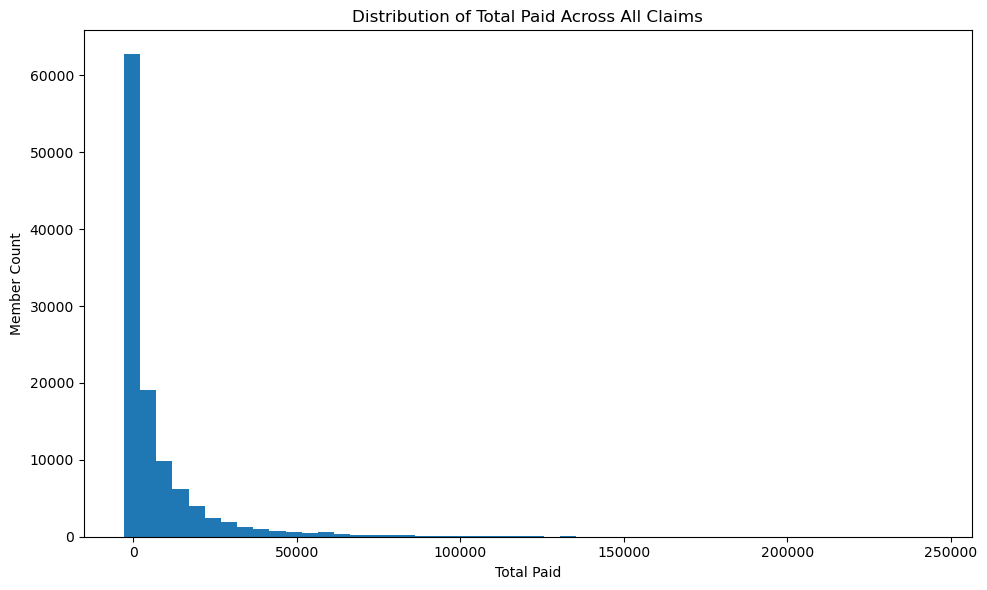

In [20]:
# hisotgram of total paid amount

plt.figure(figsize=(10, 6))
plt.hist(member_features["total_paid_all_claims"], bins=50)
plt.title("Distribution of Total Paid Across All Claims")
plt.xlabel("Total Paid")
plt.ylabel("Member Count")
plt.tight_layout()
plt.show()

C:\Users\kjdac\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


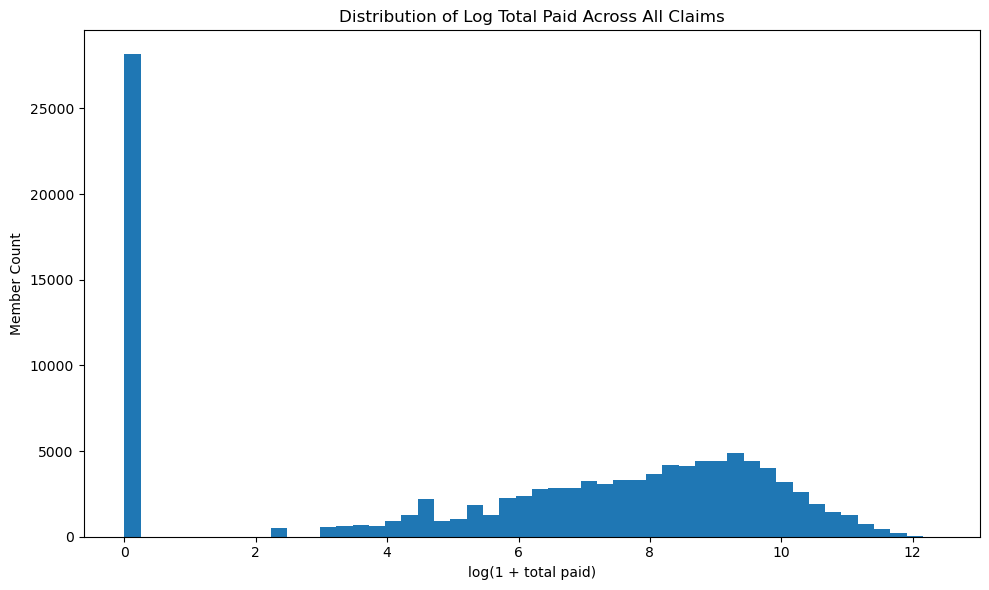

In [21]:
# histogram of log-transformed total paid

member_features["log_total_paid_all_claims"] = np.log1p(member_features["total_paid_all_claims"])

plt.figure(figsize=(10, 6))
plt.hist(member_features["log_total_paid_all_claims"], bins=50)
plt.title("Distribution of Log Total Paid Across All Claims")
plt.xlabel("log(1 + total paid)")
plt.ylabel("Member Count")
plt.tight_layout()
plt.show()

In [22]:
# save log-transformed column back to file

member_features.to_csv(
    os.path.join(processed_dir, "member_features_2010.csv"),
    index=False
)

print("Updated member_features_2010.csv with log_total_paid_all_claims.")

Updated member_features_2010.csv with log_total_paid_all_claims.


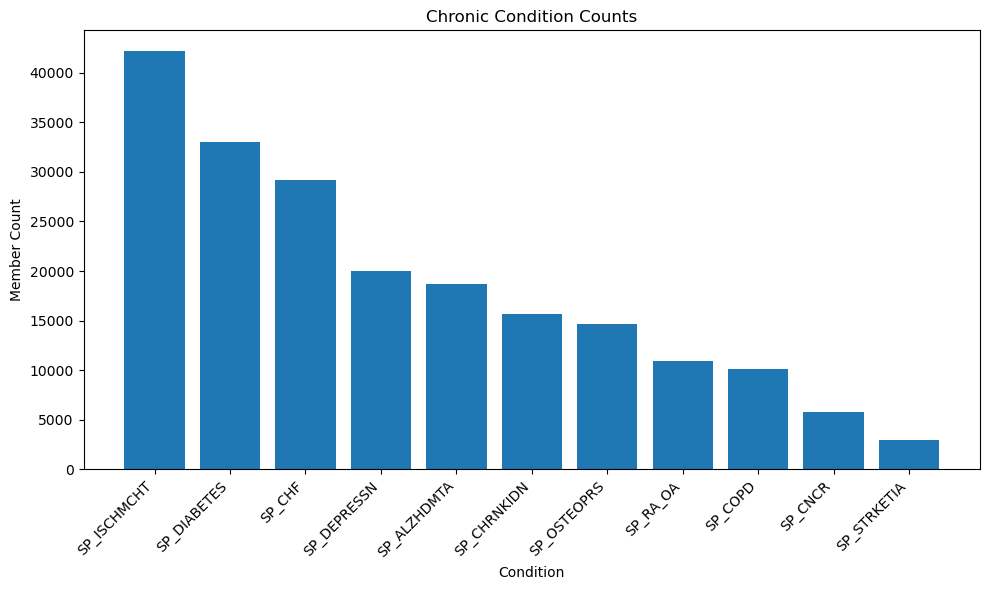

In [23]:
# bar chart of top chronic conditions

plt.figure(figsize=(10, 6))
plt.bar(chronic_summary["condition_flag"], chronic_summary["positive_count"])
plt.title("Chronic Condition Counts")
plt.xlabel("Condition")
plt.ylabel("Member Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

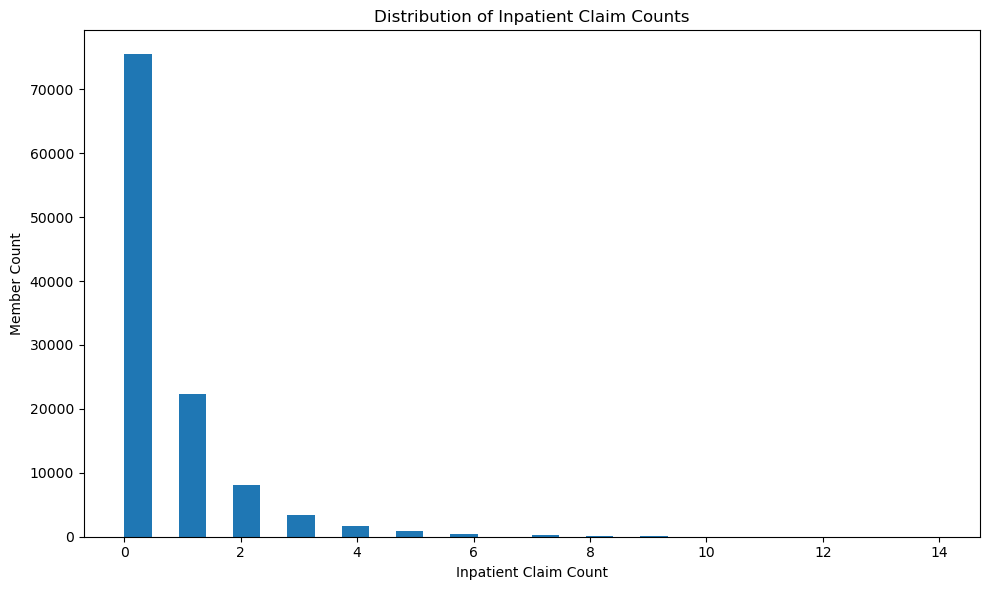

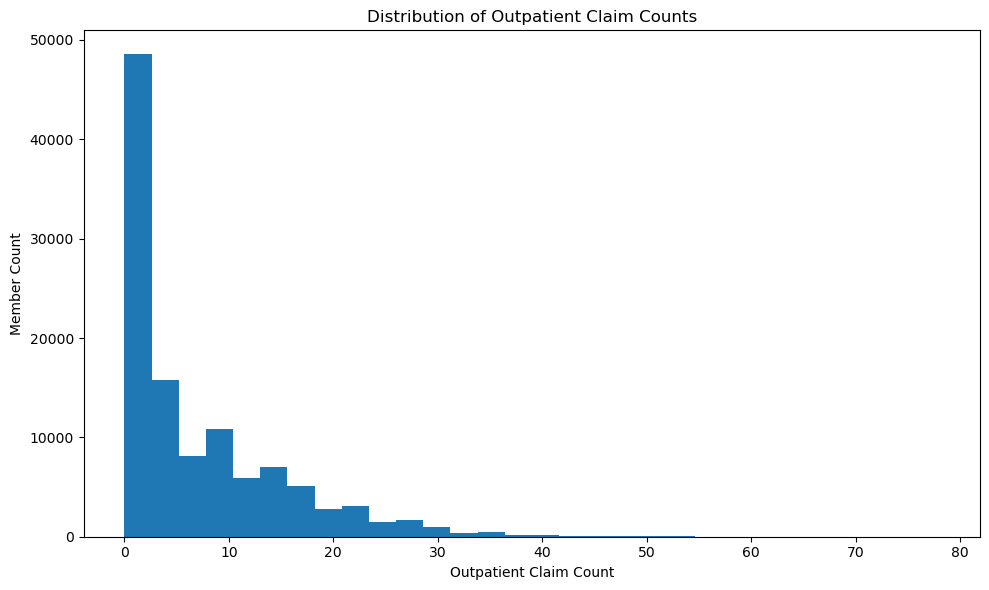

In [24]:
# inpatient vs. outpatient claim count distributions

plt.figure(figsize=(10, 6))
plt.hist(member_features["inpatient_claim_count"], bins=30)
plt.title("Distribution of Inpatient Claim Counts")
plt.xlabel("Inpatient Claim Count")
plt.ylabel("Member Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(member_features["outpatient_claim_count"], bins=30)
plt.title("Distribution of Outpatient Claim Counts")
plt.xlabel("Outpatient Claim Count")
plt.ylabel("Member Count")
plt.tight_layout()
plt.show()

In [25]:
# average utilization by chronic condition count

chronic_burden_summary = (
    member_features.groupby("chronic_condition_count")[[
        "inpatient_claim_count",
        "outpatient_claim_count",
        "total_paid_all_claims"
    ]]
    .mean()
    .round(2)
    .reset_index()
)

chronic_burden_summary

,chronic_condition_count,inpatient_claim_count,outpatient_claim_count,total_paid_all_claims
0,0,0.14,2.21,1902.25
1,1,0.43,6.77,5791.56
2,2,0.61,8.64,8029.06
3,3,0.84,10.19,10843.56
4,4,1.09,11.71,14262.98
5,5,1.32,13.06,16820.08
6,6,1.68,14.33,20691.23
7,7,2.04,15.54,24623.54
8,8,2.45,16.96,29012.55
9,9,2.76,18.13,32975.60


In [26]:
# save chronic burden summary

chronic_burden_summary.to_csv(
    os.path.join(tables_dir, "chronic_burden_summary.csv"),
    index=False
)

print("Saved chronic burden summary.")

Saved chronic burden summary.


In [27]:
# high-cost rate by chronic condition count

high_cost_by_chronic = (
    member_features.groupby("chronic_condition_count")["high_cost_member"]
    .mean()
    .round(4)
    .reset_index()
)

high_cost_by_chronic["high_cost_pct"] = high_cost_by_chronic["high_cost_member"] * 100
high_cost_by_chronic

,chronic_condition_count,high_cost_member,high_cost_pct
0,0,0.0620,6.20
1,1,0.1969,19.69
2,2,0.2794,27.94
3,3,0.3769,37.69
4,4,0.4772,47.72
5,5,0.5530,55.30
6,6,0.6443,64.43
7,7,0.7119,71.19
8,8,0.7713,77.13
9,9,0.8482,84.82


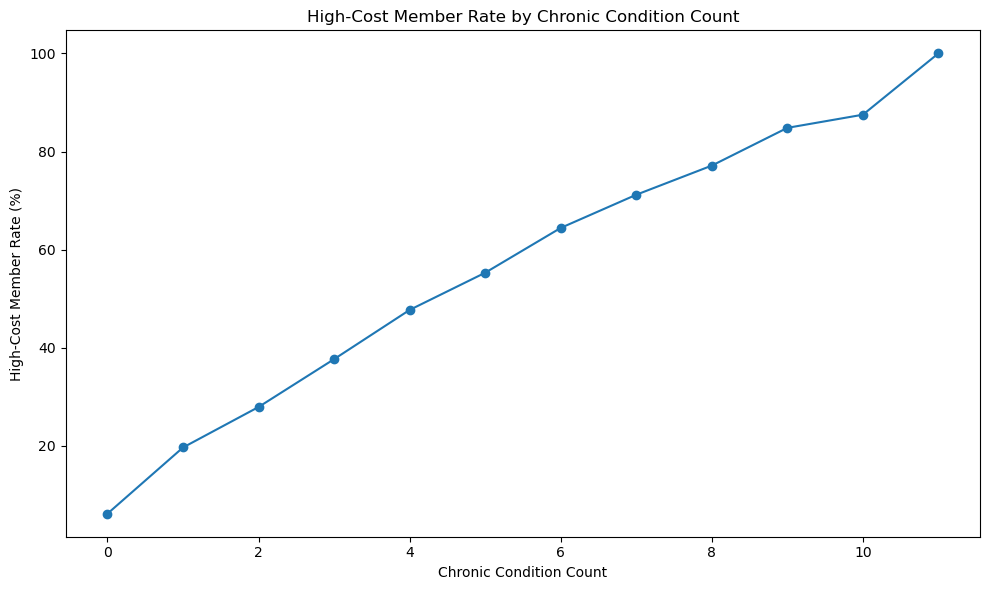

In [28]:
# plot high-cost rate by chronic condition count

plt.figure(figsize=(10, 6))
plt.plot(
    high_cost_by_chronic["chronic_condition_count"],
    high_cost_by_chronic["high_cost_pct"],
    marker="o"
)
plt.title("High-Cost Member Rate by Chronic Condition Count")
plt.xlabel("Chronic Condition Count")
plt.ylabel("High-Cost Member Rate (%)")
plt.tight_layout()
plt.show()

In [29]:
# save key exploratory tables together 

with pd.ExcelWriter(os.path.join(tables_dir, "eda_summary_tables.xlsx")) as writer:
    missing_summary.to_excel(writer, sheet_name="missingness", index=False)
    dq_flag_summary.to_excel(writer, sheet_name="dq_flags", index=False)
    chronic_summary.to_excel(writer, sheet_name="chronic_conditions", index=False)
    high_cost_summary.to_excel(writer, sheet_name="high_cost_summary", index=False)
    chronic_burden_summary.to_excel(writer, sheet_name="chronic_burden", index=False)
    high_cost_by_chronic.to_excel(writer, sheet_name="high_cost_by_chronic", index=False)

print("Saved EDA summary workbook.")

Saved EDA summary workbook.


In [30]:
# findings

print("""
Initial findings to note:
1. The member-level dataset appears to have one row per DESYNPUF_ID.
2. Claims-derived cost measures are likely right-skewed.
3. Chronic condition burden may be associated with higher utilization and higher cost.
4. Data quality checks should be reviewed before modeling.
5. High-cost members can now be profiled using demographic and claims features.
""")


Initial findings to note:
1. The member-level dataset appears to have one row per DESYNPUF_ID.
2. Claims-derived cost measures are likely right-skewed.
3. Chronic condition burden may be associated with higher utilization and higher cost.
4. Data quality checks should be reviewed before modeling.
5. High-cost members can now be profiled using demographic and claims features.

